# Building Your First Machine Learning Model with Social Network Ads

## 🚀 Introduction
In this notebook, we built a **classification model** to predict whether a user will purchase a product based on their **age** and **estimated salary**. This was your first full walkthrough of the supervised machine learning pipeline using the `scikit-learn` library.

## 📅 Dataset Overview
**Dataset:** Social Network Ads  
**Source:** [Kaggle Dataset - Rakesh Rau](https://www.kaggle.com/datasets/rakeshrau/social-network-ads/data)  
**License:** ⚠️ *Unknown license* — used strictly for educational purposes only.

### Columns:
- `User ID`: Unique identifier (not needed for modeling)
- `Gender`: Optional (excluded for simplicity)
- `Age`: Numeric feature
- `EstimatedSalary`: Numeric feature
- `Purchased`: Target label (1 = Yes, 0 = No)

---

## 🛠️ Library Setup

🎯 **Objective:** Prepare your Python environment and import the libraries needed for data handling, visualization, and model building.

In [ ]:
#!pip install scikit-learn  # Run only if sklearn is not installed

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## 🔢 Load and Inspect the Data

🎯 **Objectives:** 
- Load the dataset and understand its structure using basic inspection functions.
- Use visual tools to explore the relationship between features and the target label.

In [19]:
df = pd.read_csv("../data/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


This dataset contains 5 columns. We are mainly interested in `Age`, `EstimatedSalary`, and the target `Purchased`. `User ID` is not useful for prediction, and `Gender` will be excluded for simplicity.

## 🧐 Explore the Dataset

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


This tells us the structure of the dataset. All 400 entries are complete (no missing values), gender is of object type and all the remaining columns are of integer type.

In [21]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


Summary statistics show the distribution of numerical features.

- The average user age is ~38 years.
- The salary range goes from 15,000 to 150,000.
- The `Purchased` column has a mean of ~0.36 → indicating around 36% of users actually made a purchase.

This helps us understand the scale and balance of the data.

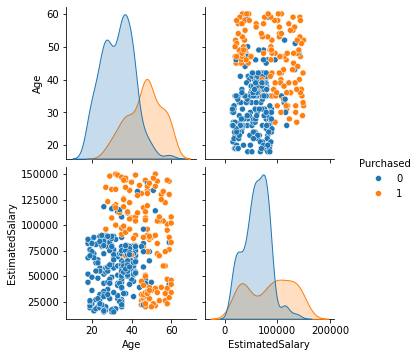

In [17]:
sns.pairplot(df, hue='Purchased')
plt.show()

Visualizing the data helps us see how Age and EstimatedSalary relate to the purchase decision. 

We notice some patterns:
- Users who **did not purchase** are mostly younger and/or lower earners.
- Users who **purchased** cluster more toward **higher age and salary**.
- This separation suggests the features can help our model distinguish classes.

---
## 📈 Prepare Your Data

🎯 **Objective:** Select relevant columns for the machine learning model.

### Drop Unnecessary Columns

In [4]:
df = df.drop(columns=["User ID", "Gender"])
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### Split into Features and Labels

In [5]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

We’re keeping only the features (`Age` and `EstimatedSalary`) and the label (`Purchased`).

---

## 🌀 Train-Test Split

🎯 **Objective:** Divide the dataset to train the model and test its performance on unseen data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


We’re training on 80% of the data and testing on 20% to evaluate generalization. This ensures the model is evaluated on unseen data.

---
## 🎯 Train the Logistic Regression Model

🎯 **Objective:** Use logistic regression to fit the model to the training data.

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

The model is now trained to find a linear decision boundary that best separates the two classes (Purchased = 0 or 1) based on Age and Salary.

---

## 📊 Predict and Evaluate

🎯 **Objective:** Evaluate the model by testing how well it predicts on unseen data.

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8875


**Accuracy** is the percentage of correct predictions on the test set. High accuracy means the model did a good job on unseen data.

An accuracy of 0.88 means 88% of predictions were correct — good performance for a simple model.

In [9]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[50  2]
 [ 7 21]]


This is the **confusion matrix**:
- True Negatives: 50
- False Positives: 2
- False Negatives: 7
- True Positives: 21

It helps evaluate which kinds of errors (false positives/negatives) the model makes.

---

## 🔁 Check for Overfitting

🎯 **Objective:** Compare training and test performance to detect overfitting.

In [25]:
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8375


The training accuracy is about **83.75%**, while the test accuracy is **88%**.  
This small difference suggests that the model **is not overfitting**—in fact, the slightly higher test accuracy could be due to random variation.  

If the training accuracy were much higher than the test accuracy, that would indicate overfitting. In this case, the model generalizes well.

---

## 🎓 Bonus: Predict New Data

🎯 **Objective:** Try predicting the outcome for a new input sample.

In [18]:
# new user infromation
new_user = pd.DataFrame([[35, 60000]], columns=["Age", "EstimatedSalary"]) # Create a DataFrame to avoid warning from sklearn about missing feature names
pred = model.predict(new_user)
print("Prediction:", pred)

Prediction: [0]


The model predicts that this new user (35 years old, salary 60,000) **would not purchase**. 

---
## 📝 Final Summary of Findings

🎯 **Objective:** Reflect on the full process and your learning outcomes.

- ✅ No missing values or inconsistencies in the data.
- 📊 Clear pattern: older and higher-earning users were more likely to purchase.
- 🤖 Our logistic regression model achieved **88% test accuracy** and **83.75% training accuracy**, showing good generalization and no signs of overfitting.
- 🧪 The confusion matrix reveals a small number of false predictions, mostly false negatives.
- 🔎 The model correctly rejected a new user with modest age and income.
- 📈 Overall, this was a strong start and shows that even simple models can make meaningful predictions.

---

## 🎉 Congratulations!


You've just completed your **first real machine learning model** — from loading data to making predictions. This is a foundational moment in your data science journey.

🚀 Keep exploring. Keep building. You're on your way to becoming a data scientist!


---